# Bài tập thực hành tuần 7
> Họ và tên: Nguyễn Vạn Phúc Huy <br>
> MSSV: 23110163 <br>
> Lớp: 23TTH (Chiều thứ 6, ca 1)

In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering

### Thực thi đoạn code ở mục 1

In [35]:
customer_data = pd.read_csv(r'D:\Data-Mining_MTH10358\Homeworks\TH\7\data.csv')
colnames = list(customer_data.columns[1:-1])
customer_data

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


Chia cột "Age" thành các nhóm khác nhau (15, 20, 30, 40, 50, 60, 70)'


In [36]:
interval = [15, 20, 30, 40, 50, 60, 70]
col = customer_data['Age']
customer_data['Age Groups'] = pd.cut(col, bins=interval)
print(customer_data['Age Groups'])

0      (15, 20]
1      (20, 30]
2      (15, 20]
3      (20, 30]
4      (30, 40]
         ...   
195    (30, 40]
196    (40, 50]
197    (30, 40]
198    (30, 40]
199    (20, 30]
Name: Age Groups, Length: 200, dtype: category
Categories (6, interval[int64, right]): [(15, 20] < (20, 30] < (30, 40] < (40, 50] < (50, 60] < (60, 70]]


In [37]:
print(customer_data.groupby('Age Groups')['Age Groups'].count())

Age Groups
(15, 20]    17
(20, 30]    45
(30, 40]    60
(40, 50]    38
(50, 60]    23
(60, 70]    17
Name: Age Groups, dtype: int64


Chuyển 2 cột Age và Genre thành dạng số

In [38]:
customer_data_oh = pd.get_dummies(customer_data, dtype='int')
print(customer_data_oh)

     CustomerID  Age  Annual Income (k$)  Spending Score (1-100)  \
0             1   19                  15                      39   
1             2   21                  15                      81   
2             3   20                  16                       6   
3             4   23                  16                      77   
4             5   31                  17                      40   
..          ...  ...                 ...                     ...   
195         196   35                 120                      79   
196         197   45                 126                      28   
197         198   32                 126                      74   
198         199   32                 137                      18   
199         200   30                 137                      83   

     Genre_Female  Genre_Male  Age Groups_(15, 20]  Age Groups_(20, 30]  \
0               0           1                    1                    0   
1               0           1    

Bỏ cột "CustomerID"

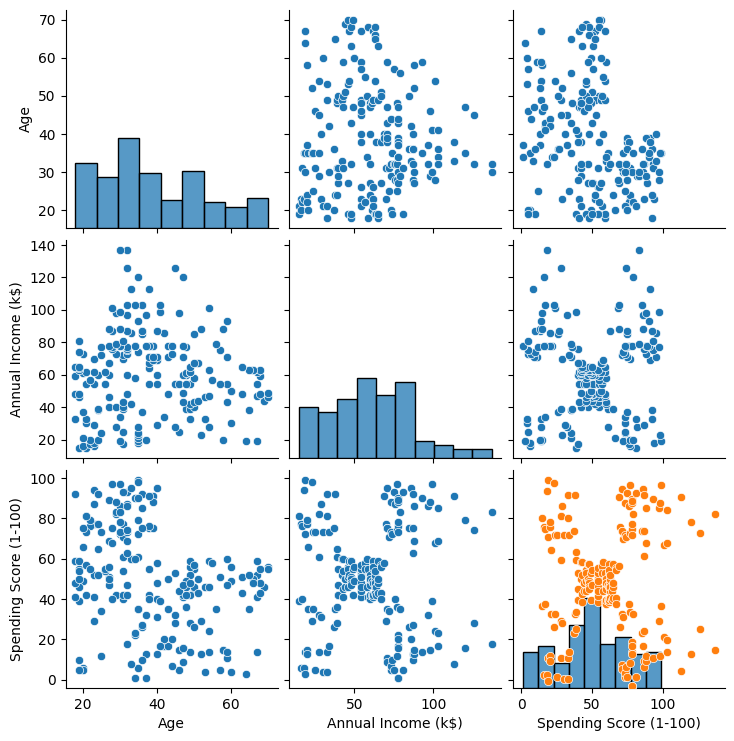

In [39]:
customer_data = customer_data.drop('CustomerID', axis=1)
sns.pairplot(customer_data)
sns.scatterplot(x = customer_data['Annual Income (k$)'], y = customer_data['Spending Score (1-100)'])
plt.show()

Bỏ cột "Age" và vẽ dendrogram

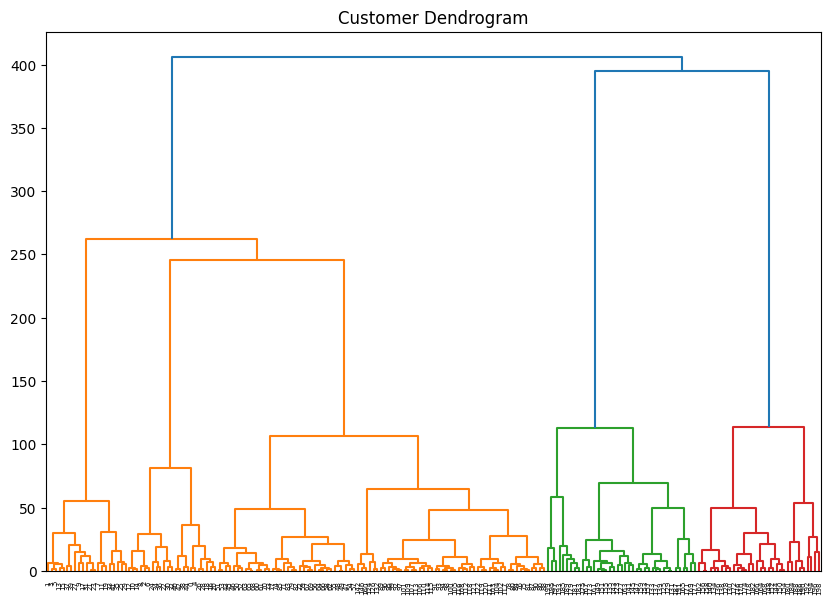

In [40]:
customer_data_oh = customer_data_oh.drop(['Age'],axis=1)
customer_data_oh.shape

plt.figure(figsize=(10, 7))
plt.title('Customer Dendrogram')

selected_data = customer_data_oh.iloc[:, 1:3]
clusters = sch.linkage(selected_data, method='ward', metric='euclidean')
sch.dendrogram(clusters)
plt.show()

Vẽ đường nằm ngang đi qua khoảng cách dài nhất

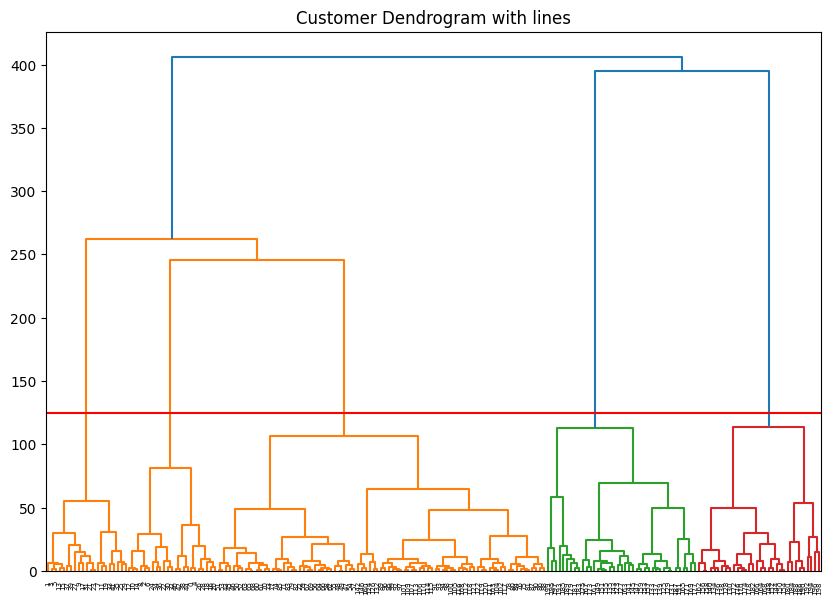

In [41]:
plt.figure(figsize=(10, 7))
plt.title('Customer Dendrogram with lines')
clusters = sch.linkage(selected_data, method='ward', metric='euclidean')
sch.dendrogram(clusters)
plt.axhline(y=125, color='r', linestyle='-')
plt.show()


Thực thi phân cụm với dữ liệu ban đầu

In [46]:
clustering_model = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
clustering_model.fit(selected_data)

data_labels = clustering_model.labels_
print(data_labels)

[4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4
 3 4 3 4 3 4 1 4 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 1 2 0 2 0 2 1 2 0 2 0 2 0 2 0 2 1 2 0 2 1 2
 0 2 0 2 0 2 0 2 0 2 0 2 1 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2]


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

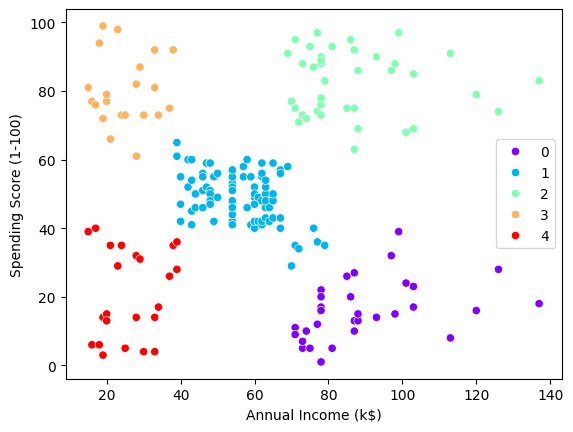

In [47]:
sns.scatterplot(x = customer_data['Annual Income (k$)'], y = customer_data['Spending Score (1-100)'],data = selected_data, hue=data_labels, palette='rainbow')

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 0 1 0 4 0 4 3 2]


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

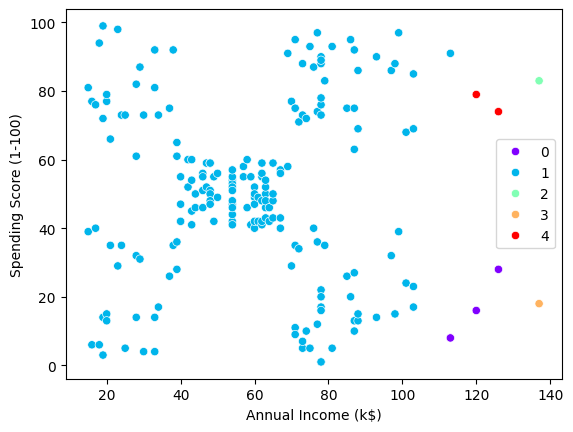

In [48]:
clustering_model_single = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='single')
clustering_model_single.fit(selected_data)

data_labels = clustering_model_single.labels_
print(data_labels)

sns.scatterplot(x = customer_data['Annual Income (k$)'], y = customer_data['Spending Score (1-100)'],data = selected_data, hue=data_labels, palette='rainbow')

### Viết chương trình để thực thi thuật toán hierarchical sử dụng phương pháp hợp nhất Bottom-up với single-linkage, complete-linkage và average-linkage.

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class AgglomerativeHierarchicalClustering:
    # Bổ sung tham số 'linkage' với giá trị mặc định là 'single'
    def __init__(self, data, K, linkage='single'):
        self.data = data.values.tolist()
        self.col = data.columns
        self.N = len(data)
        self.K = K
        self.linkage = linkage 
        self.clusters = self.init_clusters()

    def init_clusters(self):
        # Khởi tạo các cụm ban đầu, mỗi điểm dữ liệu là một cụm riêng
        return {data_id: [data_point] for data_id, data_point in enumerate(self.data)}

    # 1. Single-linkage: Khoảng cách NHỎ NHẤT
    def single_link(self, ci, cj):
        return np.min([np.linalg.norm(np.array(vi)-np.array(vj)) for vi in ci for vj in cj])

    # 2. Complete-linkage: Khoảng cách LỚN NHẤT
    def complete_link(self, ci, cj):
        return np.max([np.linalg.norm(np.array(vi)-np.array(vj)) for vi in ci for vj in cj])

    # 3. Average-linkage: Khoảng cách TRUNG BÌNH
    def average_link(self, ci, cj):
        return np.mean([np.linalg.norm(np.array(vi)-np.array(vj)) for vi in ci for vj in cj])

    # Hàm chọn phương pháp tính khoảng cách dựa trên tham số truyền vào
    def calculate_distance(self, ci, cj):
        if self.linkage == 'single':
            return self.single_link(ci, cj)
        elif self.linkage == 'complete':
            return self.complete_link(ci, cj)
        elif self.linkage == 'average':
            return self.average_link(ci, cj)
        else:
            raise ValueError("Tham số linkage phải là 'single', 'complete' hoặc 'average'")

    def find_closest_clusters(self):
        # Tìm cặp cụm có khoảng cách nhỏ nhất
        clusters_ids = list(self.clusters.keys())

        # Liệt kê tất cả các cặp có thể kết hợp
        cluster_combinations = [(clusters_ids[i], clusters_ids[j])
                                for i in range(len(clusters_ids)-1)
                                for j in range(i+1, len(clusters_ids))]

        # Tính khoảng cách giữa các cặp cụm BẰNG PHƯƠNG PHÁP ĐÃ CHỌN
        distances = [self.calculate_distance(self.clusters[ci], self.clusters[cj])
                     for ci, cj in cluster_combinations]

        # Xác định chỉ số của cặp cụm có khoảng cách nhỏ nhất
        closest_index = np.argmin(distances)
        closest_clusters = cluster_combinations[closest_index]

        return closest_clusters

    def merge_and_form_new_clusters(self, ci_id, cj_id):
        # Kết hợp hai cụm ci và cj thành một cụm mới
        new_clusters = {0: self.clusters[ci_id] + self.clusters[cj_id]}
        new_cluster_id = 1

        # Gán lại các cụm không phải là ci hay cj
        for cluster_id, points in self.clusters.items():
            if cluster_id != ci_id and cluster_id != cj_id:
                new_clusters[new_cluster_id] = points
                new_cluster_id += 1

        return new_clusters

    def run_algorithm(self):
        # Thực hiện thuật toán cho đến khi số cụm bằng K
        while len(self.clusters.keys()) > self.K:
            closest_clusters = self.find_closest_clusters()
            self.clusters = self.merge_and_form_new_clusters(*closest_clusters)

    def print(self):
        # In ra thông tin của các cụm
        print(f"--- Kết quả gom cụm bằng phương pháp: {self.linkage.upper()}-LINKAGE ---")
        for cluster_id, points in self.clusters.items():
            print("Cluster: {}".format(cluster_id))
            for point in points:
                print("    {}".format(point))

    def plot_clusters(self):
        # Vẽ biểu đồ các cụm
        cluster_ids = list(self.clusters.keys())
        num_clusters = len(cluster_ids)
        colors = sns.color_palette('rainbow', n_colors=num_clusters)
        fig, ax = plt.subplots()
        
        for i, cluster_id in enumerate(cluster_ids):
            points = self.clusters[cluster_id]
            x = [point[0] for point in points]
            y = [point[1] for point in points]
            ax.scatter(x, y, color=colors[i], label=f'Cluster {cluster_id}')
            
        ax.set_xlabel(self.col[0])
        ax.set_ylabel(self.col[1]) # Đã sửa thành set_ylabel
        ax.set_title(f'Hierarchical Clustering ({self.linkage}-linkage)')

        ax.legend()
        plt.show()

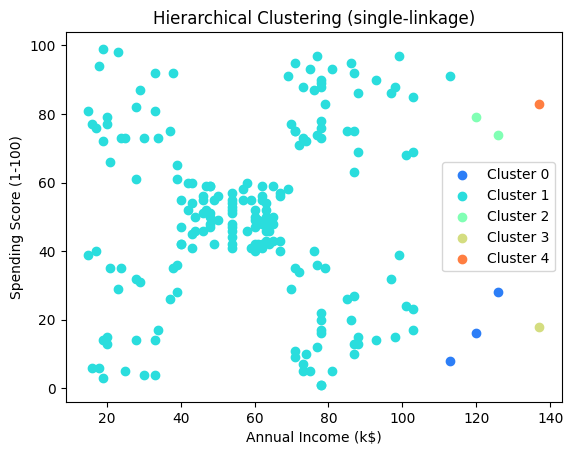

In [45]:
agg_hierarchical_clustering = AgglomerativeHierarchicalClustering(selected_data, 5)
agg_hierarchical_clustering.run_algorithm()
agg_hierarchical_clustering.plot_clusters()